In [ ]:
# rutas del proyecto (ver modules/paths.py)
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from modules.paths import RAW, PROC, OUT


In [2]:
import pandas as pd
log_path = PROC / "2026-08-18/prueba_03-cont-f13.csv"
df_log = pd.read_csv(log_path, dtype=str)
df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,1787236544237,7E4DACAE00000000,D11EB701,14BBB333,2A9F0000,12000000,4C000000,A2190000,B9000000,ECFFFFFF,E2FFFFFF,63FDFFFF,7E4DACAE00000000D11EB70114BBB3332A9F0000120000...
1,1787236544237,E24DACAE00000000,2D1FB701,1FBBB333,2A9F0000,12000000,4C000000,9A190000,16010000,E1FFFFFF,D2FFFFFF,5BFDFFFF,E24DACAE000000002D1FB7011FBBB3332A9F0000120000...
2,1787236544237,464EACAE00000000,8A1FB701,2ABBB333,2A9F0000,12000000,4C000000,90190000,72010000,D6FFFFFF,C2FFFFFF,51FDFFFF,464EACAE000000008A1FB7012ABBB3332A9F0000120000...
3,1787236544237,AA4EACAE00000000,E61FB701,35BBB333,2A9F0000,12000000,4C000000,84190000,CE010000,CAFFFFFF,B3FFFFFF,45FDFFFF,AA4EACAE00000000E61FB70135BBB3332A9F0000120000...
4,1787236544237,0F4FACAE00000000,4320B701,40BBB333,2A9F0000,12000000,4C000000,78190000,2B020000,BFFFFFFF,A3FFFFFF,39FDFFFF,0F4FACAE000000004320B70140BBB3332A9F0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13945,1787237996237,B474C2AE00000000,3B4FB701,AEC8B333,DD9D0000,12000000,4C000000,AE3E0000,D6180000,E1010000,30FBFFFF,E71F0000,B474C2AE000000003B4FB701AEC8B333DD9D0000120000...
13946,1787237996237,1975C2AE00000000,3B4FB701,AEC8B333,DD9D0000,12000000,4C000000,AE3E0000,D6180000,E1010000,30FBFFFF,E71F0000,1975C2AE000000003B4FB701AEC8B333DD9D0000120000...
13947,1787237996237,7C75C2AE00000000,3B4FB701,AEC8B333,DD9D0000,12000000,4C000000,AE3E0000,D6180000,E1010000,30FBFFFF,E71F0000,7C75C2AE000000003B4FB701AEC8B333DD9D0000120000...
13948,1787237996237,E175C2AE00000000,3B4FB701,AEC8B333,DD9D0000,12000000,4C000000,AE3E0000,D6180000,E1010000,30FBFFFF,E71F0000,E175C2AE000000003B4FB701AEC8B333DD9D0000120000...


In [3]:
# Columnas hexadecimales little-endian (excluimos 'time' que ya es decimal, y 'raw' que es la concatenación)
hex_cols = [c for c in df_log.columns if c not in ("time", "raw")]

def hex_to_int(x):
    return int.from_bytes(bytes.fromhex(x), byteorder="little", signed=True)

for column in hex_cols:
    df_log[column] = df_log[column].apply(hex_to_int)

# 'time' es epoch en ms (entero decimal), lo convertimos aparte
df_log["time"] = df_log["time"].astype("int64")

df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,1787236544237,2930527614,28778193,867416852,40746,18,76,6562,185,-20,-30,-669,7E4DACAE00000000D11EB70114BBB3332A9F0000120000...
1,1787236544237,2930527714,28778285,867416863,40746,18,76,6554,278,-31,-46,-677,E24DACAE000000002D1FB7011FBBB3332A9F0000120000...
2,1787236544237,2930527814,28778378,867416874,40746,18,76,6544,370,-42,-62,-687,464EACAE000000008A1FB7012ABBB3332A9F0000120000...
3,1787236544237,2930527914,28778470,867416885,40746,18,76,6532,462,-54,-77,-699,AA4EACAE00000000E61FB70135BBB3332A9F0000120000...
4,1787236544237,2930528015,28778563,867416896,40746,18,76,6520,555,-65,-93,-711,0F4FACAE000000004320B70140BBB3332A9F0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13945,1787237996237,2931979444,28790587,867420334,40413,18,76,16046,6358,481,-1232,8167,B474C2AE000000003B4FB701AEC8B333DD9D0000120000...
13946,1787237996237,2931979545,28790587,867420334,40413,18,76,16046,6358,481,-1232,8167,1975C2AE000000003B4FB701AEC8B333DD9D0000120000...
13947,1787237996237,2931979644,28790587,867420334,40413,18,76,16046,6358,481,-1232,8167,7C75C2AE000000003B4FB701AEC8B333DD9D0000120000...
13948,1787237996237,2931979745,28790587,867420334,40413,18,76,16046,6358,481,-1232,8167,E175C2AE000000003B4FB701AEC8B333DD9D0000120000...


In [4]:
# Escalado a unidades reales (confirmado contra ControlBox_prueba1.db y por consistencia interna)
# Todos los enteros vienen en centesimas (valor x100): posicion/altura en cm, angulos en centesimas de grado.
#   z=11622 -> 116.22 (IBeacon.altitude), heading=29549 -> 295.49 (HeadingBeacon=295.5)
#   inx_x=99985 -> 999.85 m ~= distancia UTM recorrida (~993 m)
#   inx_yaw=-136 -> -1.36 deg ~= variacion de heading (-1.23 deg)

df_log["utm_x"]   = df_log["utm_x"] / 100.0        # m (UTM Este)
df_log["utm_y"]   = df_log["utm_y"] / 100.0        # m (UTM Norte)
df_log["z"]       = df_log["z"] / 100.0            # m (altura)
df_log["heading"] = df_log["heading"] / 100.0      # grados

df_log["utm_zone_l"] = df_log["utm_zone_l"].apply(chr)   # 76 -> 'L'
# utm_zone_n queda como entero (18)

# Offsets INS relativos a la baliza (mismo factor: centesimas)
df_log["inx_x"]   = df_log["inx_x"] / 100.0        # m
df_log["inx_y"]   = df_log["inx_y"] / 100.0        # m
df_log["inx_z"]   = df_log["inx_z"] / 100.0        # m
df_log["inx_yaw"] = df_log["inx_yaw"] / 100.0      # grados

# time a datetime (epoch ms)
df_log["time"] = pd.to_datetime(df_log["time"], unit="ms")

df_log

,time,ts,utm_x,utm_y,z,utm_zone_n,utm_zone_l,heading,inx_x,inx_y,inx_z,inx_yaw,raw
0,2026-08-20 14:35:44.237,2930527614,287781.93,8674168.52,407.46,18,L,65.62,1.85,-0.20,-0.30,-6.69,7E4DACAE00000000D11EB70114BBB3332A9F0000120000...
1,2026-08-20 14:35:44.237,2930527714,287782.85,8674168.63,407.46,18,L,65.54,2.78,-0.31,-0.46,-6.77,E24DACAE000000002D1FB7011FBBB3332A9F0000120000...
2,2026-08-20 14:35:44.237,2930527814,287783.78,8674168.74,407.46,18,L,65.44,3.70,-0.42,-0.62,-6.87,464EACAE000000008A1FB7012ABBB3332A9F0000120000...
3,2026-08-20 14:35:44.237,2930527914,287784.70,8674168.85,407.46,18,L,65.32,4.62,-0.54,-0.77,-6.99,AA4EACAE00000000E61FB70135BBB3332A9F0000120000...
4,2026-08-20 14:35:44.237,2930528015,287785.63,8674168.96,407.46,18,L,65.20,5.55,-0.65,-0.93,-7.11,0F4FACAE000000004320B70140BBB3332A9F0000120000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13945,2026-08-20 14:59:56.237,2931979444,287905.87,8674203.34,404.13,18,L,160.46,63.58,4.81,-12.32,81.67,B474C2AE000000003B4FB701AEC8B333DD9D0000120000...
13946,2026-08-20 14:59:56.237,2931979545,287905.87,8674203.34,404.13,18,L,160.46,63.58,4.81,-12.32,81.67,1975C2AE000000003B4FB701AEC8B333DD9D0000120000...
13947,2026-08-20 14:59:56.237,2931979644,287905.87,8674203.34,404.13,18,L,160.46,63.58,4.81,-12.32,81.67,7C75C2AE000000003B4FB701AEC8B333DD9D0000120000...
13948,2026-08-20 14:59:56.237,2931979745,287905.87,8674203.34,404.13,18,L,160.46,63.58,4.81,-12.32,81.67,E175C2AE000000003B4FB701AEC8B333DD9D0000120000...


In [5]:
df_log.to_csv(OUT / "verificacion_ins.csv", index=False)

In [6]:
def plot_window(df, ts_array="t_rel", data_array=None):# plt.figure(figsize=(10, 5))
    plt.plot(df[ts_array], df[data_array], label=data_array)
    # plt.xlabel("Hora")
    # plt.ylabel("Velocidad [km/h]")
    # plt.title("Velocidad vehicular OBD-II sincronizada")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

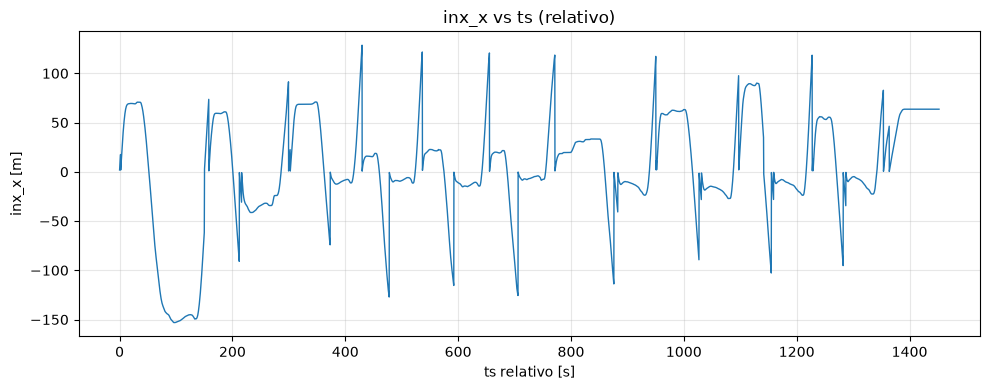

In [7]:
import matplotlib.pyplot as plt

# ts relativo en segundos (1 unidad de ts ~ 1 ms)
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

# 1) inx_x vs ts (relativo)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_rel, df_log["inx_x"], lw=1)
ax.set_xlabel("ts relativo [s]")
ax.set_ylabel("inx_x [m]")
ax.set_title("inx_x vs ts (relativo)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

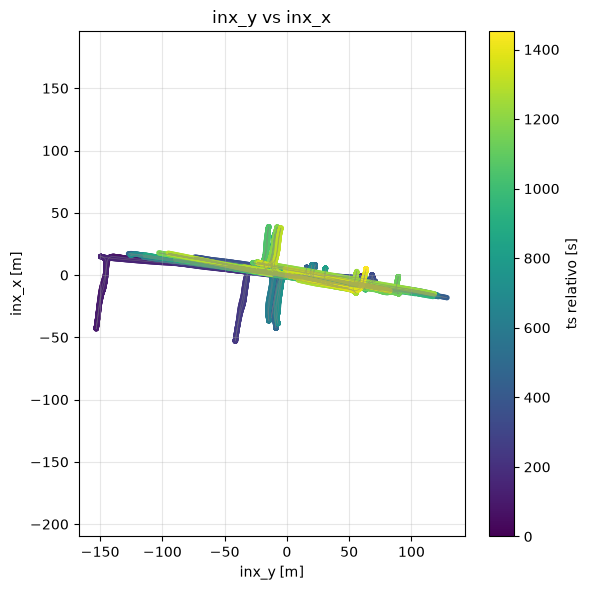

In [8]:
# 2) inx_x vs inx_y (trayectoria en el plano local del INS)
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(df_log["inx_x"], df_log["inx_y"], c=t_rel, cmap="viridis", s=8)
ax.plot(df_log["inx_x"], df_log["inx_y"], lw=0.5, color="gray", alpha=0.5)
ax.set_xlabel("inx_y [m]")
ax.set_ylabel("inx_x [m]")
ax.set_title("inx_y vs inx_x")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label="ts relativo [s]")
plt.tight_layout()
plt.show()

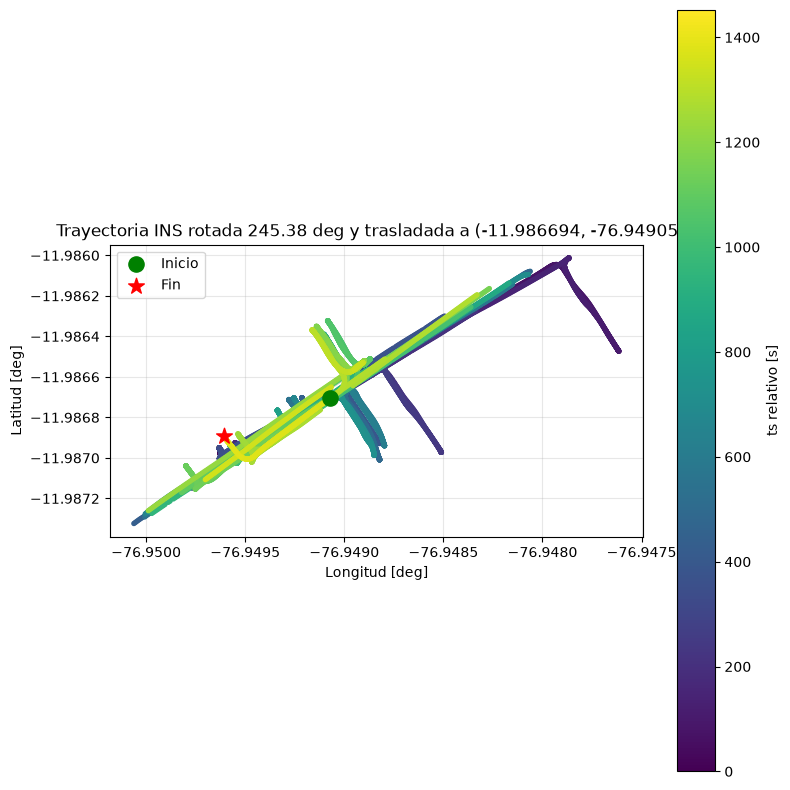

In [9]:
# Trayectoria INS rotada 295.5 respecto al Norte y trasladada al punto inicial (lat/lon)
import numpy as np

# 1) Rotacion NED por el heading del beacon (295.5 sobre el Norte) -> offsets Este/Norte [m]
PSI = 245.38#123.88#124.55#245.38
r = np.radians(PSI)
# est_E = df_log["inx_x"] * np.sin(r) - df_log["inx_y"] * np.cos(r)   # Este  [m]
# est_N = df_log["inx_x"] * np.cos(r) + df_log["inx_y"] * np.sin(r)   # Norte [m]

est_N = df_log["inx_x"] * np.cos(r) - df_log["inx_y"] * np.sin(r)   # Norte [m]
est_E = df_log["inx_x"] * np.sin(r) + df_log["inx_y"] * np.cos(r)   # Este  [m]

# 2) Traslacion: punto inicial en lat/lon (IBeacon) + offsets en metros -> lat/lon
lat0, lon0 = -11.986694,-76.949058#-12.091589, -76.989728#-12.091514, -76.989831#-11.986164, -76.947892
M_PER_DEG_LAT = 111320.0
lat = lat0 + est_N / M_PER_DEG_LAT
lon = lon0 + est_E / (M_PER_DEG_LAT * np.cos(np.radians(lat0)))

# 3) Plot lon (X) vs lat (Y)
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(lon, lat, c=t_rel, cmap="viridis", s=8, zorder=2)
ax.plot(lon, lat, lw=0.5, color="gray", alpha=0.5, zorder=1)

ax.scatter(lon.iloc[0],  lat.iloc[0],  color="green", s=120, marker="o", zorder=3, label="Inicio")
ax.scatter(lon.iloc[-1], lat.iloc[-1], color="red",   s=140, marker="*", zorder=3, label="Fin")

ax.set_xlabel("Longitud [deg]")
ax.set_ylabel("Latitud [deg]")
ax.set_title(f"Trayectoria INS rotada {PSI} deg y trasladada a ({lat0}, {lon0})")
ax.set_aspect(1 / np.cos(np.radians(lat0)))   # metros iguales se ven iguales
ax.ticklabel_format(useOffset=False, style="plain")
ax.grid(True, alpha=0.3)
ax.legend()
fig.colorbar(sc, ax=ax, label="ts relativo [s]")
plt.tight_layout()
plt.show()

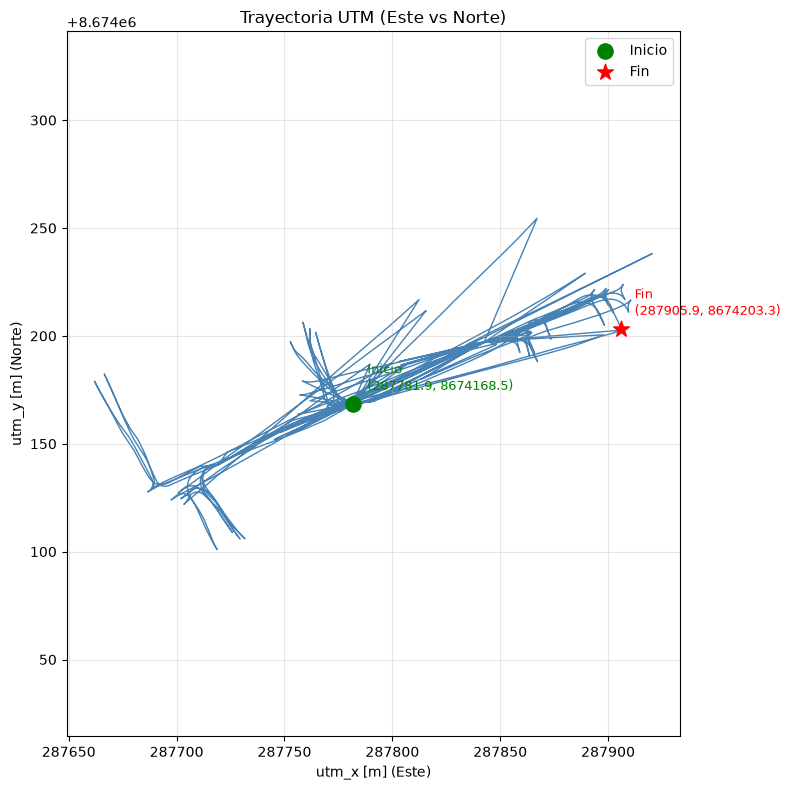

In [10]:
# Trayectoria UTM con identificadores de inicio y fin
# utm_x = Este (Easting, ~279717), utm_y = Norte (Northing, ~8661585)
# Mapa correcto: Este en el eje X, Norte en el eje Y
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(df_log["utm_x"], df_log["utm_y"], lw=1, color="steelblue", zorder=1)

# Punto inicial y final
x0, y0 = df_log["utm_x"].iloc[0],  df_log["utm_y"].iloc[0]
xf, yf = df_log["utm_x"].iloc[-1], df_log["utm_y"].iloc[-1]

ax.scatter(x0, y0, color="green", s=120, marker="o", zorder=3, label="Inicio")
ax.scatter(xf, yf, color="red",   s=140, marker="*", zorder=3, label="Fin")

ax.annotate(f"Inicio\n({x0:.1f}, {y0:.1f})", (x0, y0),
            textcoords="offset points", xytext=(10, 10), color="green", fontsize=9)
ax.annotate(f"Fin\n({xf:.1f}, {yf:.1f})", (xf, yf),
            textcoords="offset points", xytext=(10, 10), color="red", fontsize=9)

ax.set_xlabel("utm_x [m] (Este)")
ax.set_ylabel("utm_y [m] (Norte)")
ax.set_title("Trayectoria UTM (Este vs Norte)")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
np.sqrt((278821.8 - 279717.5) **2 + (8661997.3 - 8661568.1)**2)

np.float64(993.2225984143636)

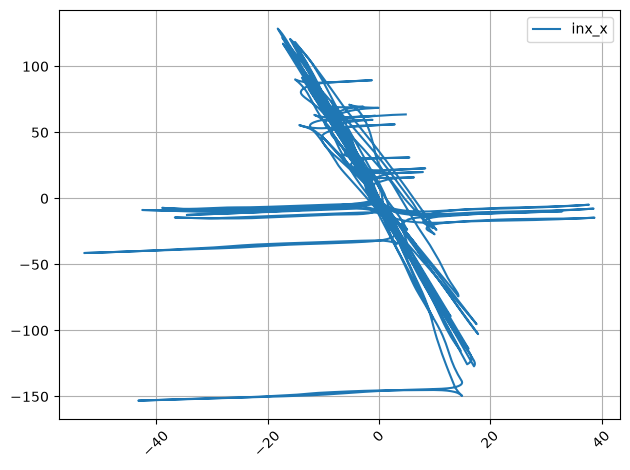

In [12]:
plot_window(df_log, ts_array="inx_y", data_array="inx_x")

In [13]:
# Trayectoria sobre un mapa real (folium / OpenStreetMap)
# Usa lat/lon calculados en la celda de rotacion+traslacion (825...)
import folium

coords = list(zip(lat, lon))

# Mapa centrado en el punto inicial
m = folium.Map(location=[lat0, lon0], zoom_start=18, tiles="OpenStreetMap")

# Linea de la trayectoria
folium.PolyLine(coords, color="blue", weight=3, opacity=0.8,
                tooltip="Trayectoria INS").add_to(m)

# Marcadores inicio / fin
folium.Marker([lat.iloc[0], lon.iloc[0]], tooltip="Inicio",
              icon=folium.Icon(color="green", icon="play")).add_to(m)
folium.Marker([lat.iloc[-1], lon.iloc[-1]], tooltip="Fin",
              icon=folium.Icon(color="red", icon="stop")).add_to(m)

# Punto del beacon (origen)
folium.CircleMarker([lat0, lon0], radius=5, color="black", fill=True,
                    fill_opacity=1, tooltip="Beacon (origen)").add_to(m)

# Ajusta el zoom para que quepa toda la trayectoria
m.fit_bounds(coords)

# Guarda una copia en HTML (por si se quiere abrir aparte) y muestra inline
m.save(str(OUT / "trayectoria_mapa.html"))
m

In [14]:
# Trayectoria UTM directa sobre un mapa real (folium / OpenStreetMap)
# En vez de los datos relativos del INS, usa utm_x/utm_y convertidos a lat/lon.
import folium
import utm

# Zona UTM del log (utm_zone_n = numero, utm_zone_l = letra de banda, p.ej. 18 'L')
zn = int(df_log["utm_zone_n"].iloc[0])
zl = df_log["utm_zone_l"].iloc[0]

lat_utm, lon_utm = utm.to_latlon(df_log["utm_x"].to_numpy(),
                                 df_log["utm_y"].to_numpy(), zn, zl)

coords_utm = list(zip(lat_utm, lon_utm))

# Mapa centrado en el primer punto UTM
m_utm = folium.Map(location=[lat_utm[0], lon_utm[0]], zoom_start=18, tiles="OpenStreetMap")

folium.PolyLine(coords_utm, color="purple", weight=3, opacity=0.8,
                tooltip="Trayectoria UTM (GNSS)").add_to(m_utm)

folium.Marker([lat_utm[0], lon_utm[0]], tooltip="Inicio",
              icon=folium.Icon(color="green", icon="play")).add_to(m_utm)
folium.Marker([lat_utm[-1], lon_utm[-1]], tooltip="Fin",
              icon=folium.Icon(color="red", icon="stop")).add_to(m_utm)

m_utm.fit_bounds(coords_utm)

# Guarda el segundo HTML y muestra inline
m_utm.save(str(OUT / "trayectoria_utm_mapa.html"))
m_utm

In [15]:
# Widget interactivo: generacion de la trayectoria UTM segun el tiempo (barra deslizante)
# Usa lat_utm/lon_utm de la celda anterior (datos UTM del GNSS). Slider = tiempo; boton Play anima.
import numpy as np
import plotly.graph_objects as go

t_s = (df_log["ts"].to_numpy() - df_log["ts"].iloc[0]) / 1000.0   # tiempo relativo [s]
lat_a = np.asarray(lat_utm)
lon_a = np.asarray(lon_utm)

# Submuestreo a un numero manejable de frames
n_frames = 200
idx = np.unique(np.linspace(0, len(lat_a) - 1, n_frames).astype(int))
lat_d, lon_d, t_d = lat_a[idx], lon_a[idx], t_s[idx]


def _frame(k):
    return [
        go.Scattermap(lat=lat_d[:k + 1], lon=lon_d[:k + 1], mode="lines",
                      line=dict(color="purple", width=3), name="trayectoria"),
        go.Scattermap(lat=[lat_d[k]], lon=[lon_d[k]], mode="markers",
                      marker=dict(size=12, color="red"), name="posicion"),
    ]


frames = [go.Frame(data=_frame(k), name=f"{t_d[k]:.0f}") for k in range(len(idx))]
fig = go.Figure(data=_frame(0), frames=frames)

slider = dict(
    active=0,
    currentvalue=dict(prefix="t = ", suffix=" s"),
    pad=dict(t=40),
    steps=[dict(method="animate", label=f"{t_d[k]:.0f}",
                args=[[f"{t_d[k]:.0f}"],
                      dict(mode="immediate", frame=dict(duration=0, redraw=True),
                           transition=dict(duration=0))])
           for k in range(len(idx))],
)

play = dict(
    type="buttons", showactive=False, x=0.05, y=0, xanchor="right", yanchor="top",
    buttons=[
        dict(label="▶ Play", method="animate",
             args=[None, dict(frame=dict(duration=80, redraw=True),
                              fromcurrent=True, transition=dict(duration=0))]),
        dict(label="⏸ Pause", method="animate",
             args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")]),
    ],
)

fig.update_layout(
    map=dict(style="open-street-map",
             center=dict(lat=float(lat_a.mean()), lon=float(lon_a.mean())), zoom=15),
    margin=dict(l=0, r=0, t=40, b=0),
    height=600,
    title="Generacion de la trayectoria UTM segun el tiempo",
    sliders=[slider],
    updatemenus=[play],
)

fig.show()

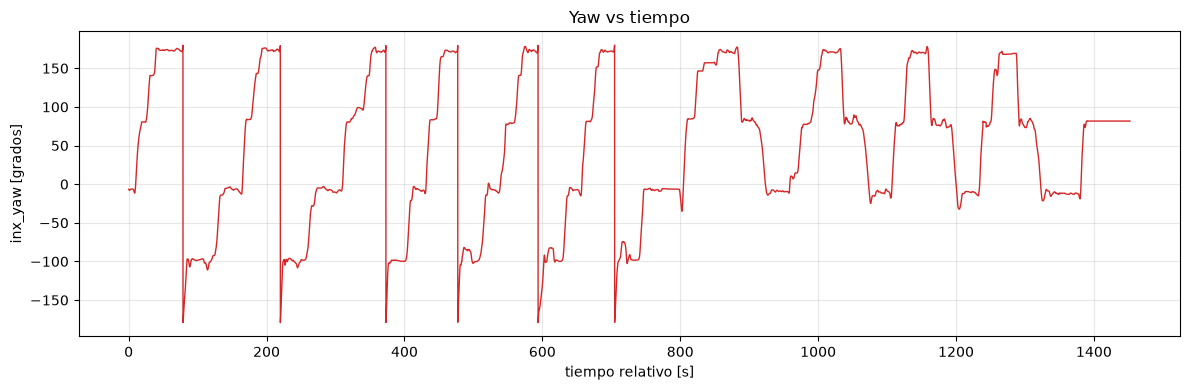

In [16]:
# yaw (inx_yaw) vs tiempo
# ts relativo en segundos (1 unidad de ts ~ 1 ms)
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_rel, df_log["inx_yaw"], lw=1, color="tab:red")
ax.set_xlabel("tiempo relativo [s]")
ax.set_ylabel("inx_yaw [grados]")
ax.set_title("Yaw vs tiempo")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

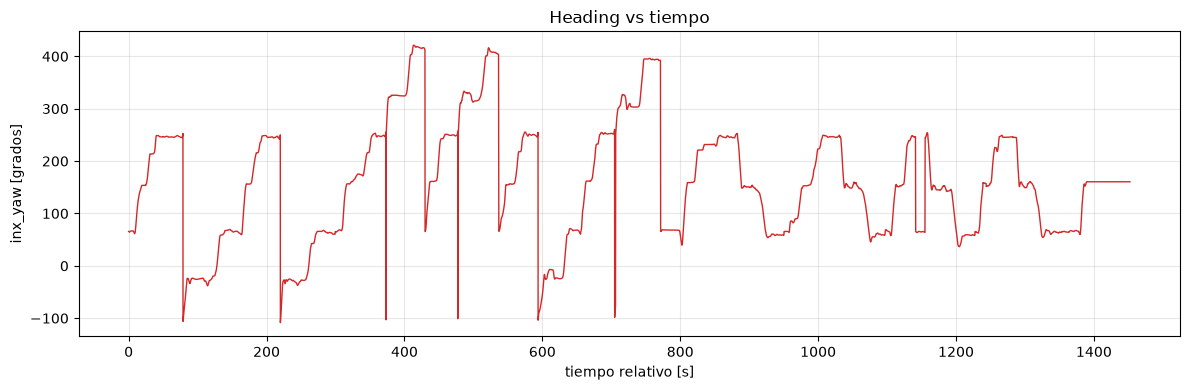

In [17]:
t_rel = (df_log["ts"] - df_log["ts"].iloc[0]) / 1000.0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_rel, df_log["heading"], lw=1, color="tab:red")
ax.set_xlabel("tiempo relativo [s]")
ax.set_ylabel("inx_yaw [grados]")
ax.set_title("Heading vs tiempo")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Funciones de ploteo por prueba

Funciones reutilizables para analizar una prueba individual (un CSV): decodificacion, deteccion
del giro (inversion de sentido) y las graficas de diagnostico, una por prueba:
- `plot_trayectoria_tiempo` : trayectoria local coloreada por tiempo + perfil de velocidad
- `plot_legs` : tramos ida/vuelta separados por el giro
- `plot_vs_utm` : INS (rotado + trasladado) vs UTM real del GNSS
- `plot_integracion_velocidad` : rapidez integrada con signo (+ ida, - vuelta)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def cargar_prueba(path):
    """Lee un CSV crudo, decodifica los hex little-endian y escala a unidades reales."""
    df = pd.read_csv(path, dtype=str)
    hex_cols = [c for c in df.columns if c not in ("time", "raw")]
    for c in hex_cols:
        df[c] = df[c].apply(lambda x: int.from_bytes(bytes.fromhex(x), "little", signed=True))
    for c in ["utm_x", "utm_y", "z", "heading", "inx_x", "inx_y", "inx_z", "inx_yaw"]:
        df[c] = df[c] / 100.0
    # tiempo relativo en segundos (ts ~ ms)
    df["t"] = (df["ts"] - df["ts"].iloc[0]) / 1000.0
    return df


def giro_idx(df):
    """Detecta el instante de inversion de sentido (giro) como el extremo interior
    de la proyeccion de la trayectoria sobre su eje principal (PCA)."""
    u = df.drop_duplicates(subset=["inx_x", "inx_y"]).reset_index()   # 'index' = idx original
    P = u[["inx_x", "inx_y"]].to_numpy()
    Pc = P - P.mean(0)
    _, _, Vt = np.linalg.svd(Pc, full_matrices=False)
    s = pd.Series(Pc @ Vt[0])
    ss = s.rolling(41, center=True, min_periods=1).median()
    N = len(u)
    cands = [int(ss.idxmin()), int(ss.idxmax())]
    interior = [c for c in cands if 0.08 * N < c < 0.92 * N]
    k = interior[0] if interior else min(cands, key=lambda c: abs(c - N / 2))
    return int(u["index"].iloc[k])   # indice en df original


def _dist_dt(df):
    """Distancia entre muestras [m] y dt [s] (dt<=0 -> NaN)."""
    dt = df["t"].diff()
    dd = np.hypot(df["inx_x"].diff(), df["inx_y"].diff())
    return dd, dt.where(dt > 0)


def _velocidad(df):
    dd, dt = _dist_dt(df)
    return dd.div(dt)   # dt NaN donde dt<=0 -> evita division por cero


def plot_trayectoria_tiempo(df, name=""):
    """Trayectoria local (inx_y vs inx_x) coloreada por tiempo + perfil de velocidad."""
    v = _velocidad(df).rolling(15, min_periods=1).median()
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6))
    sc = a1.scatter(df["inx_y"], df["inx_x"], c=df["t"], cmap="turbo", s=8)
    a1.plot(df["inx_y"], df["inx_x"], lw=0.3, color="gray", alpha=0.4)
    a1.scatter(df["inx_y"].iloc[0], df["inx_x"].iloc[0], c="k", s=90, marker="o", label="inicio")
    a1.scatter(df["inx_y"].iloc[-1], df["inx_x"].iloc[-1], c="r", s=110, marker="*", label="fin")
    a1.set_xlabel("inx_y [m]"); a1.set_ylabel("inx_x [m]")
    a1.set_title(f"{name} - trayectoria (color = tiempo)")
    a1.set_aspect("equal", adjustable="datalim"); a1.grid(alpha=0.3); a1.legend()
    fig.colorbar(sc, ax=a1, label="t [s]")
    a2.plot(df["t"], v, lw=0.8)
    a2.set_xlabel("t [s]"); a2.set_ylabel("v [m/s]")
    a2.set_title(f"{name} - velocidad"); a2.set_ylim(0, 6); a2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_legs(df, name="", itp=None):
    """Separa y grafica los tramos de ida (antes del giro) y vuelta (despues)."""
    if itp is None:
        itp = giro_idx(df)
    fwd, ret = df.iloc[:itp + 1], df.iloc[itp:]
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot(fwd["inx_y"], fwd["inx_x"], "b-", lw=1, label="ida")
    ax.plot(ret["inx_y"], ret["inx_x"], "r-", lw=1, label="vuelta")
    ax.scatter(df["inx_y"].iloc[0], df["inx_x"].iloc[0], c="k", s=90, marker="o", zorder=5, label="inicio")
    ax.scatter(df["inx_y"].iloc[itp], df["inx_x"].iloc[itp], c="lime", s=130, marker="D", zorder=5, label="giro")
    ax.set_xlabel("inx_y [m]"); ax.set_ylabel("inx_x [m]")
    ax.set_title(f"{name} - ida / vuelta (giro en t={df['t'].iloc[itp]:.0f}s)")
    ax.set_aspect("equal", adjustable="datalim"); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()


def plot_vs_utm(df, name="", psi=295.5):
    """INS rotado (psi) y trasladado al primer UTM, comparado con el UTM real del GNSS."""
    r = np.radians(psi)
    eN = df["inx_x"] * np.cos(r) - df["inx_y"] * np.sin(r)
    eE = df["inx_x"] * np.sin(r) + df["inx_y"] * np.cos(r)
    ex = df["utm_x"].iloc[0] + eE
    ey = df["utm_y"].iloc[0] + eN
    itp = giro_idx(df)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(df["utm_x"], df["utm_y"], "k-", lw=1.5, alpha=0.7, label="UTM real (GNSS)")
    ax.plot(ex.iloc[:itp + 1], ey.iloc[:itp + 1], "b-", lw=1, label="INS ida")
    ax.plot(ex.iloc[itp:], ey.iloc[itp:], "r-", lw=1, label="INS vuelta")
    ax.set_xlabel("Este [m]"); ax.set_ylabel("Norte [m]")
    ax.set_title(f"{name} - INS (rot {psi} deg) vs UTM real")
    ax.set_aspect("equal", adjustable="datalim"); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()


def plot_integracion_velocidad(df, name="", itp=None):
    """Integra la rapidez con signo: + hasta el giro, - despues (distancia con signo)."""
    if itp is None:
        itp = giro_idx(df)
    dd, dt = _dist_dt(df)
    ds = dd.fillna(0).to_numpy()                       # distancia entre muestras [m]
    sign = np.where(np.arange(len(df)) <= itp, 1.0, -1.0)
    s_signed = np.cumsum(sign * ds)                    # distancia recorrida con signo
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["t"], s_signed, lw=1.2)
    ax.axvline(df["t"].iloc[itp], color="g", ls="--", lw=1.5, label="giro")
    ax.scatter(df["t"].iloc[itp], s_signed[itp], color="lime", s=90, marker="D", zorder=5)
    ax.set_xlabel("t [s]"); ax.set_ylabel("dist. recorrida (con signo) [m]")
    ax.set_title(f"{name} - integracion de velocidad (+ ida / - vuelta)")
    ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

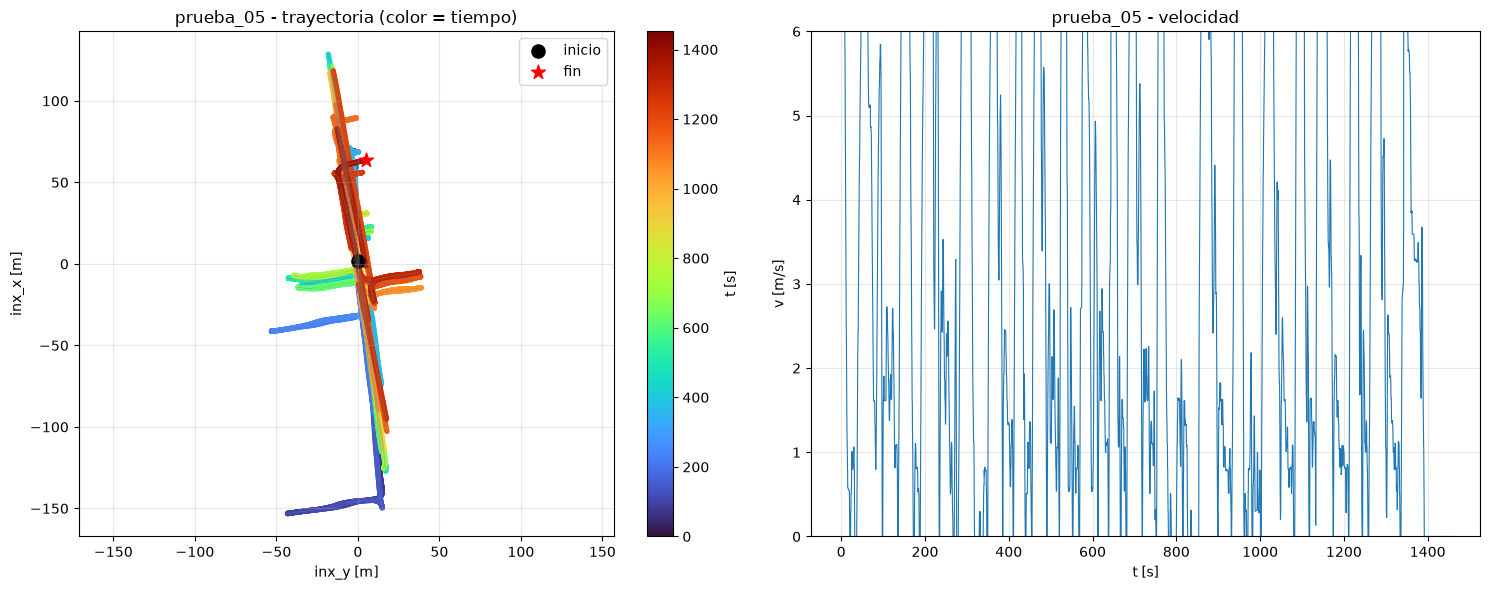

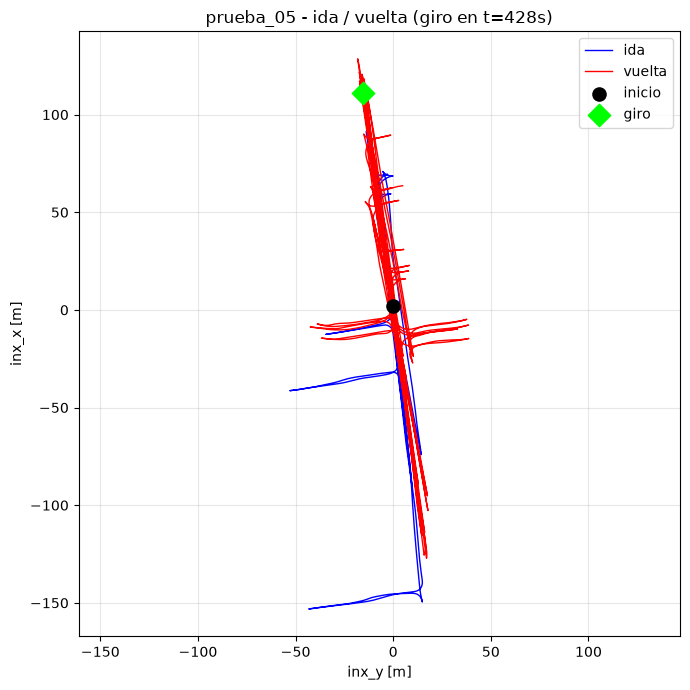

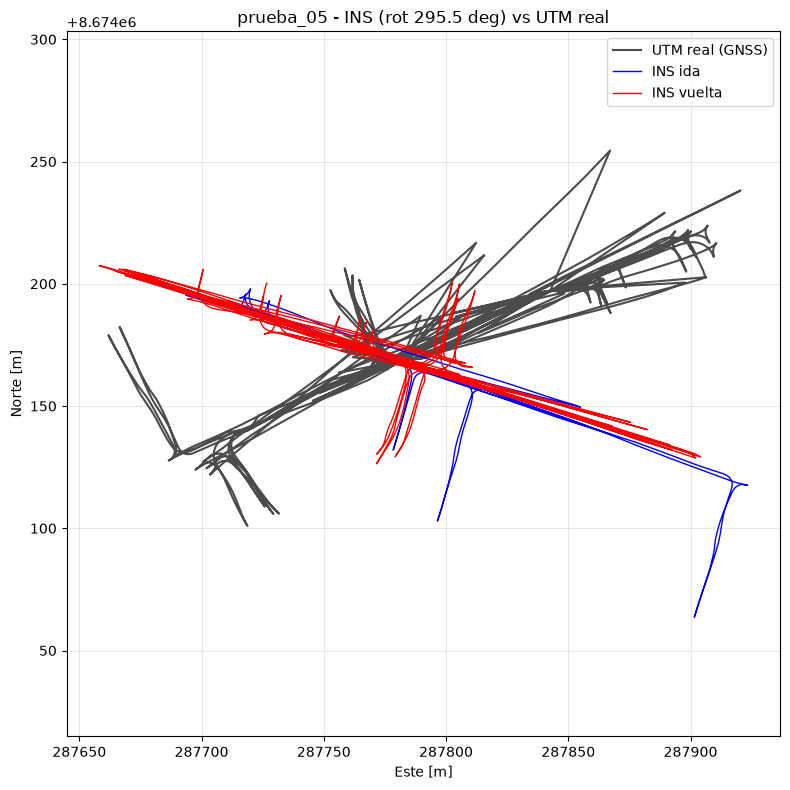

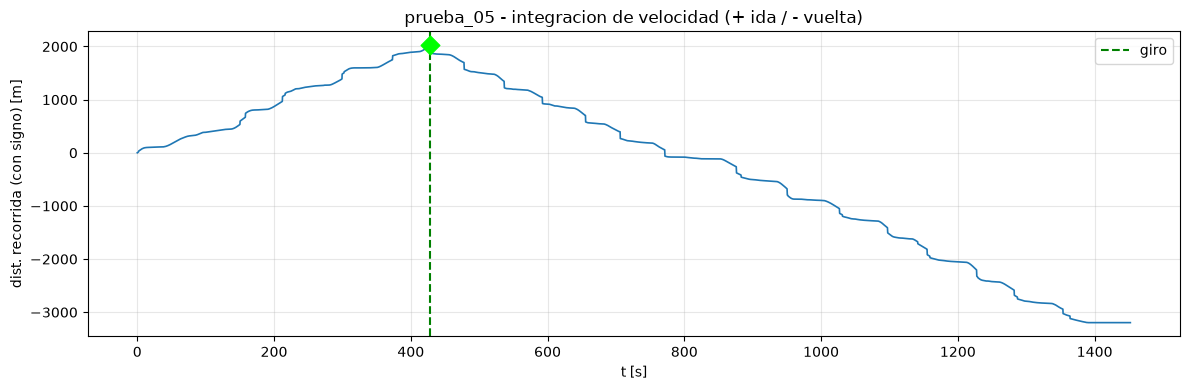

In [19]:
# Uso: analizar una prueba individual
prueba = cargar_prueba(log_path)
nombre = "prueba_05"

plot_trayectoria_tiempo(prueba, nombre)
plot_legs(prueba, nombre)
plot_vs_utm(prueba, nombre, psi=295.5)
plot_integracion_velocidad(prueba, nombre)